<a href="https://colab.research.google.com/github/bishwa011/ML-PRACTICES/blob/main/ML_learning_lab_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (confusion_matrix)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import plotly.express as px

Generate a dataset with 100 samples and 5 features using numpy.random.rand

Also generate corresponding target labels using numpy.random.randint

Then split and test

In [4]:
np.random.seed(42)

num_samples = 100
num_features = 5
X = np.random.rand(num_samples, num_features)
y = np.random.randint(0,2,size=num_samples)

x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
print("Train set shape", x_train.shape, y_train.shape)
print("Test set shape", x_test.shape, y_test.shape)

Train set shape (80, 5) (80,)
Test set shape (20, 5) (20,)


Classification

In [8]:
np.random.seed(42)

X = np.random.rand(200,4)
y = np.random.randint(0,2, size = 200)

x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

model = LogisticRegression()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

cm=confusion_matrix(y_test, y_pred)

tp = cm[1,1]
fp = cm[0,1]
fn = cm[1,0]
tn = cm[0,0]

accuracy = (tp + tn) / (tp + tn+ fp+fn)
precision = tp / (tp+fp)
recall = tp / (tp+fn)

specificity = tn/(tn+fp)

f1 = 2*(precision*recall) / (precision + recall)

#print all
print("Confusion Matrix:", cm)
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print("Specificity:", specificity)
print('F1 Score:', f1)

Confusion Matrix: [[20  3]
 [13  4]]
Accuracy: 0.6
Precision: 0.5714285714285714
Recall: 0.23529411764705882
Specificity: 0.8695652173913043
F1 Score: 0.3333333333333333


Regression

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)

#Generate random data
X = np.random.rand(200,1) #input feature
y = 2 + 3 * X + np.random.randn(200,1) #True relation + random noise

#spliting

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

#model creation
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

#Evaluation

mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print('Mean Squared Error:', mse)
print(f'Root Mean Squared Error: {rmse:.2f}')
print('Mean Absolute Error:', mae)
print('R-squared:', r2)




Mean Squared Error: 1.0846238625454692
Root Mean Squared Error: 1.08
Mean Absolute Error: 0.8387402733729706
R-squared: 0.240964423634343


Unsupervised learning

Dimensionality Reduction using principal component analysis (PCA)

Original shape:  (105, 5)
Accuracy on original dataset: 1.0
Transformed shape:  (105, 2)


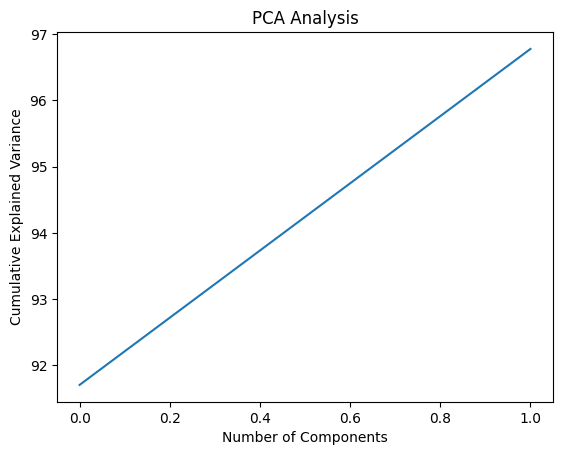

Accuracy on transformed dataset: 1.0


In [11]:
#load data iris from plotly.express
df = px.data.iris()

#Extract feature and target variable
X = df.drop('species', axis=1).values
y = df['species'].values

#Logistic regression on original dataset

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Original shape: ", X_train.shape)

lr_original = LogisticRegression()
lr_original.fit(X_train, y_train)
y_pred_original = lr_original.predict(X_test)
cm = confusion_matrix(y_test, y_pred_original)
tp = cm[1, 1]  # True Positives
fp = cm[0, 1]  # False Positives
fn = cm[1, 0]  # False Negatives
tn = cm[0, 0]  # True Negatives
accuracy_original = (tp + tn) / (tp + tn + fp + fn)
print('Accuracy on original dataset:', accuracy_original)


#Perform PCA
covar_matrix = PCA(n_components=2) ## The n_components parameter determines the number of dimensions the data will be reduced to.
X_train_transformed = covar_matrix.fit_transform(X_train) # fits the PCA model to the training data X_train and simultaneously applies the transformation.
print("Transformed shape: ", X_train_transformed.shape)
X_test_transformed = covar_matrix.transform(X_test) # projects the testing data onto the same reduced feature space as the training data
variance = covar_matrix.explained_variance_ratio_ #calculate variance ratios
var = np.cumsum(np.round(covar_matrix.explained_variance_ratio_, decimals = 6) * 100) # Cumulative sum of variance explained with [n] features

# Plot explained variance
plt.ylabel('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.title('PCA Analysis')
plt.plot(var)
plt.show()


#Logistic regression on the transformed dataset

lr_transformed = LogisticRegression()
lr_transformed.fit(X_train_transformed, y_train)
y_pred_transformed = lr_transformed.predict(X_test_transformed)
cm_transformed = confusion_matrix(y_test, y_pred_transformed)

cm_transformed = confusion_matrix(y_test, y_pred_transformed)
tp = cm_transformed[1, 1]  # True Positives
fp = cm_transformed[0, 1]  # False Positives
fn = cm_transformed[1, 0]  # False Negatives
tn = cm_transformed[0, 0]  # True Negatives
accuracy_transformed = (tp + tn) / (tp + tn + fp + fn)
print('Accuracy on transformed dataset:', accuracy_transformed)







Exercise 1 - Build a linear regression with the dataset below and evaluate the model

In [12]:

# Load the california_housing dataset having a continuous target variable.
data = datasets.fetch_california_housing()
# Make a DataFrame
df = pd.DataFrame(np.column_stack([data['data'], data['target']]), columns=data['feature_names'] + ['target'])
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [13]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:8],df['target'], test_size = 0.3, random_state = 0)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print('Mean Squared Error:', mse)
print(f'Root Mean Squared Error: {rmse:.2f}')
print('Mean Absolute Error:', mae)
print('R-squared:', r2)



Mean Squared Error: 0.5431489670037241
Root Mean Squared Error: 0.54
Mean Absolute Error: 0.5361818140641839
R-squared: 0.5926087785518774


Exercise 2 - Build a logistic regression with the dataset below and evaluate the model

In [14]:
# Load the california_housing dataset having a continuous target variable.
data = datasets.fetch_california_housing()
# Make a DataFrame
df = pd.DataFrame(np.column_stack([data['data'], data['target']]), columns=data['feature_names'] + ['target'])
df['target'] = df['target'].apply(lambda x: 1 if x > df['target'].mean() else 0)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,1
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,1
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,1
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,1
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,1


In [15]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :8], df['target'], test_size=0.3, random_state = 0)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# True Positives
tp = cm[1, 1]
# False Positives
fp = cm[0, 1]
# False Negatives
fn = cm[1, 0]
# True Negatives
tn = cm[0, 0]

# Accuracy
accuracy = (tp + tn) / (tp + tn + fp + fn)
# Precision
precision = tp / (tp + fp)
# Recall
recall = tp / (tp + fn)
# Specificity
specificity = tn / (tn + fp)
# F1 Score
f1 = 2 * (precision * recall) / (precision + recall)


# Print the evaluation metrics
print("Confusion Matrix:", cm)
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print("Specificity:", specificity)
print('F1 Score:', f1)


Confusion Matrix: [[3213  473]
 [ 769 1737]]
Accuracy: 0.7994186046511628
Precision: 0.785972850678733
Recall: 0.6931364724660815
Specificity: 0.8716766142159522
F1 Score: 0.7366412213740459


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Eercise 3 - Perform PCA on the data below to plot the corresponding Cumulative Explained Variance

In [16]:
np.random.seed(0)
X_train = np.random.rand(100, 8)  # 100 samples with 8 features
X_test = np.random.rand(50, 8)  # 50 samples with 8 features

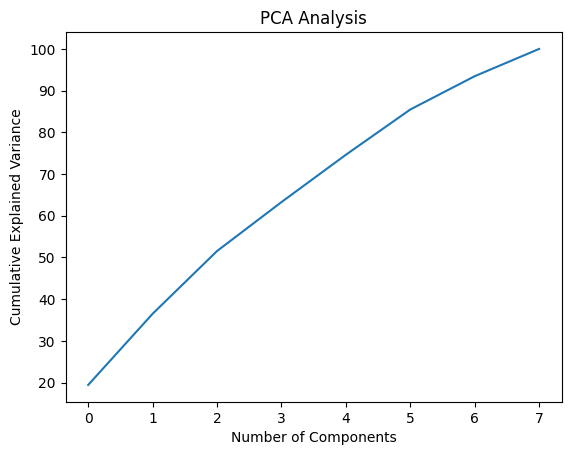

In [21]:
#perform PCA
covar_matrix = PCA(n_components = 8) #SInce 8 features
X_train_pca = covar_matrix.fit_transform(X_train)
X_test_pca = covar_matrix.transform(X_test)
variance = covar_matrix.explained_variance_ratio_
#calculate variance ratios
var = np.cumsum(np.round(covar_matrix.explained_variance_ratio_, decimals=6) * 100)

# Plot explained variance
plt.ylabel('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.title('PCA Analysis')
plt.plot(var)
plt.show()
